<div class="alert alert-block alert-success">
    <h1 align="center">Diabetic Retinopathy Classification</h1>
    <h3 align="center">Image Classification</h3>
    
<a href="https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered">
About Dataset
    </a>
    <br />
<a href="https://appdiabeticretinopathyclassification-cyoxaklhammfssbqmxgg4y.streamlit.app/">
Diabetic Retinopathy Detection - Streamlit App
    </a>
</div>

<img src="https://da4e1j5r7gw87.cloudfront.net/wp-content/uploads/sites/2470/2022/07/4-stages-diabetic-retinopathy.jpg" 
     style="width: 100%; max-width: 1200px; height: 350px; object-fit: cover; display: block; margin: 0 auto; border-radius: 8px;">

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to my Notebook...! 
    </h2>
    <p style="text-align: justify; margin-bottom: 20px;">
This notebook presents the development of a deep learning model for **Diabetic Retinopathy detection and classification** in retinal fundus images. Using MobileNet architecture with Transfer Learning and fine-tuning, we aim to automatically and accurately identify the presence and severity of diabetic retinopathy, assisting ophthalmologists in early diagnosis and preventing vision loss in diabetic patients.
    </p>
<p style="text-align: justify; margin-bottom: 20px;">
Diabetic retinopathy is a diabetes complication that affects eyes. It's caused by damage to the blood vessels of the light-sensitive tissue at the back of the eye (retina). At first, diabetic retinopathy may cause no symptoms or only mild vision problems.
</p>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="margin-bottom:10px;">
        This project uses the APTOS 2019 Blindness Detection dataset, which contains retinal fundus images labeled according to the severity of Diabetic Retinopathy. The images are categorized into five classes:
    </p>
    <ul style="margin:0;padding-left:35px; text-align: justify; padding-top: 10px;">
         <li style="margin-bottom:14px;">
            No_DR: No diabetic retinopathy.
        </li>
         <li style="margin-bottom:14px;">
            Mild: Mild diabetic retinopathy.
        </li>
         <li style="margin-bottom:14px;">
            Moderate: Moderate diabetic retinopathy.
        </li>
         <li style="margin-bottom:14px;">
            Severe: Severe diabetic retinopathy.
        </li>
        <li style="margin-bottom:14px;">
            Proliferate_DR: Proliferative diabetic retinopathy.
        </li>
    </ul>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Install required libraries
    </p>
</div>

In [1]:
!pip install -U tf2onnx onnx onnxruntime

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Import required libraries
    </p>
</div>

In [2]:
import os
import seaborn as sns
import cv2
import pandas as pd
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
#---
import tensorflow as tf
from tensorflow import keras
#---
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
#---
import tf2onnx, onnx
#---
#Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.2 Paths & quick inspect
    </p>
</div>

In [3]:
base_model = keras.applications.MobileNetV2(include_top=False, input_shape=(224,224,3), weights='imagenet')
#---
BATCH_SIZE = 32
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE
root_dir = "/kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images"

I0000 00:00:1784921682.930164    1869 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.3 Extracting Image Paths and Labels from Directory
    </p>
</div>

In [4]:
def get_image_paths_labels(directory):
    directory = Path(directory)
    image_paths = []
    labels = []
    class_names = sorted([item.name for item in directory.glob("*") if item.is_dir()])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = directory / class_name
        for img_path in class_dir.glob("*.*"):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                image_paths.append(str(img_path))
                labels.append(class_to_idx[class_name])

    return image_paths, labels, class_names

all_images, all_labels, label_names = get_image_paths_labels(root_dir)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Data Overview
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Distribution of Skin Lesion Classes in Training Dataset
         </li>
        </ul>
</div>

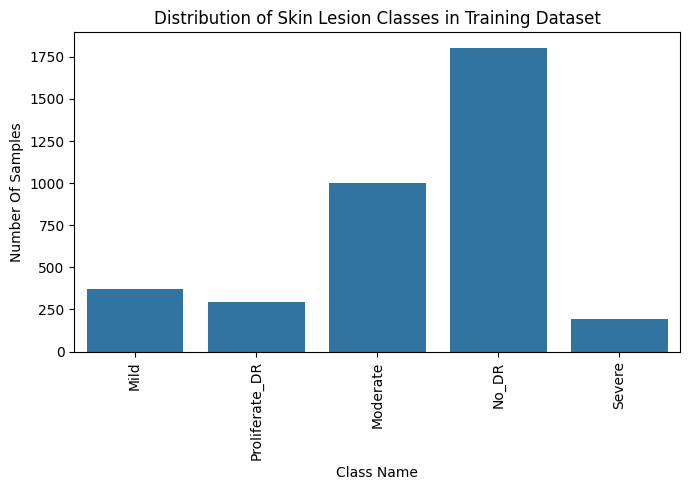

In [5]:
class_names = []
counts = []

for class_name in os.listdir(root_dir):
    if class_name =='export.pkl':
        continue
    class_dir = os.path.join(root_dir, class_name)
    if os.path.isdir(class_dir):
        count = len(os.listdir(class_dir))
        class_names.append(class_name)
        counts.append(count)

df = pd.DataFrame({'Class': class_names, 'num_of_samples': counts})

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Class', y='num_of_samples')
plt.title('Distribution of Skin Lesion Classes in Training Dataset')
plt.xlabel('Class Name')
plt.ylabel('Number Of Samples')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Visualizing Dataset Samples
         </li>
        </ul>
</div>

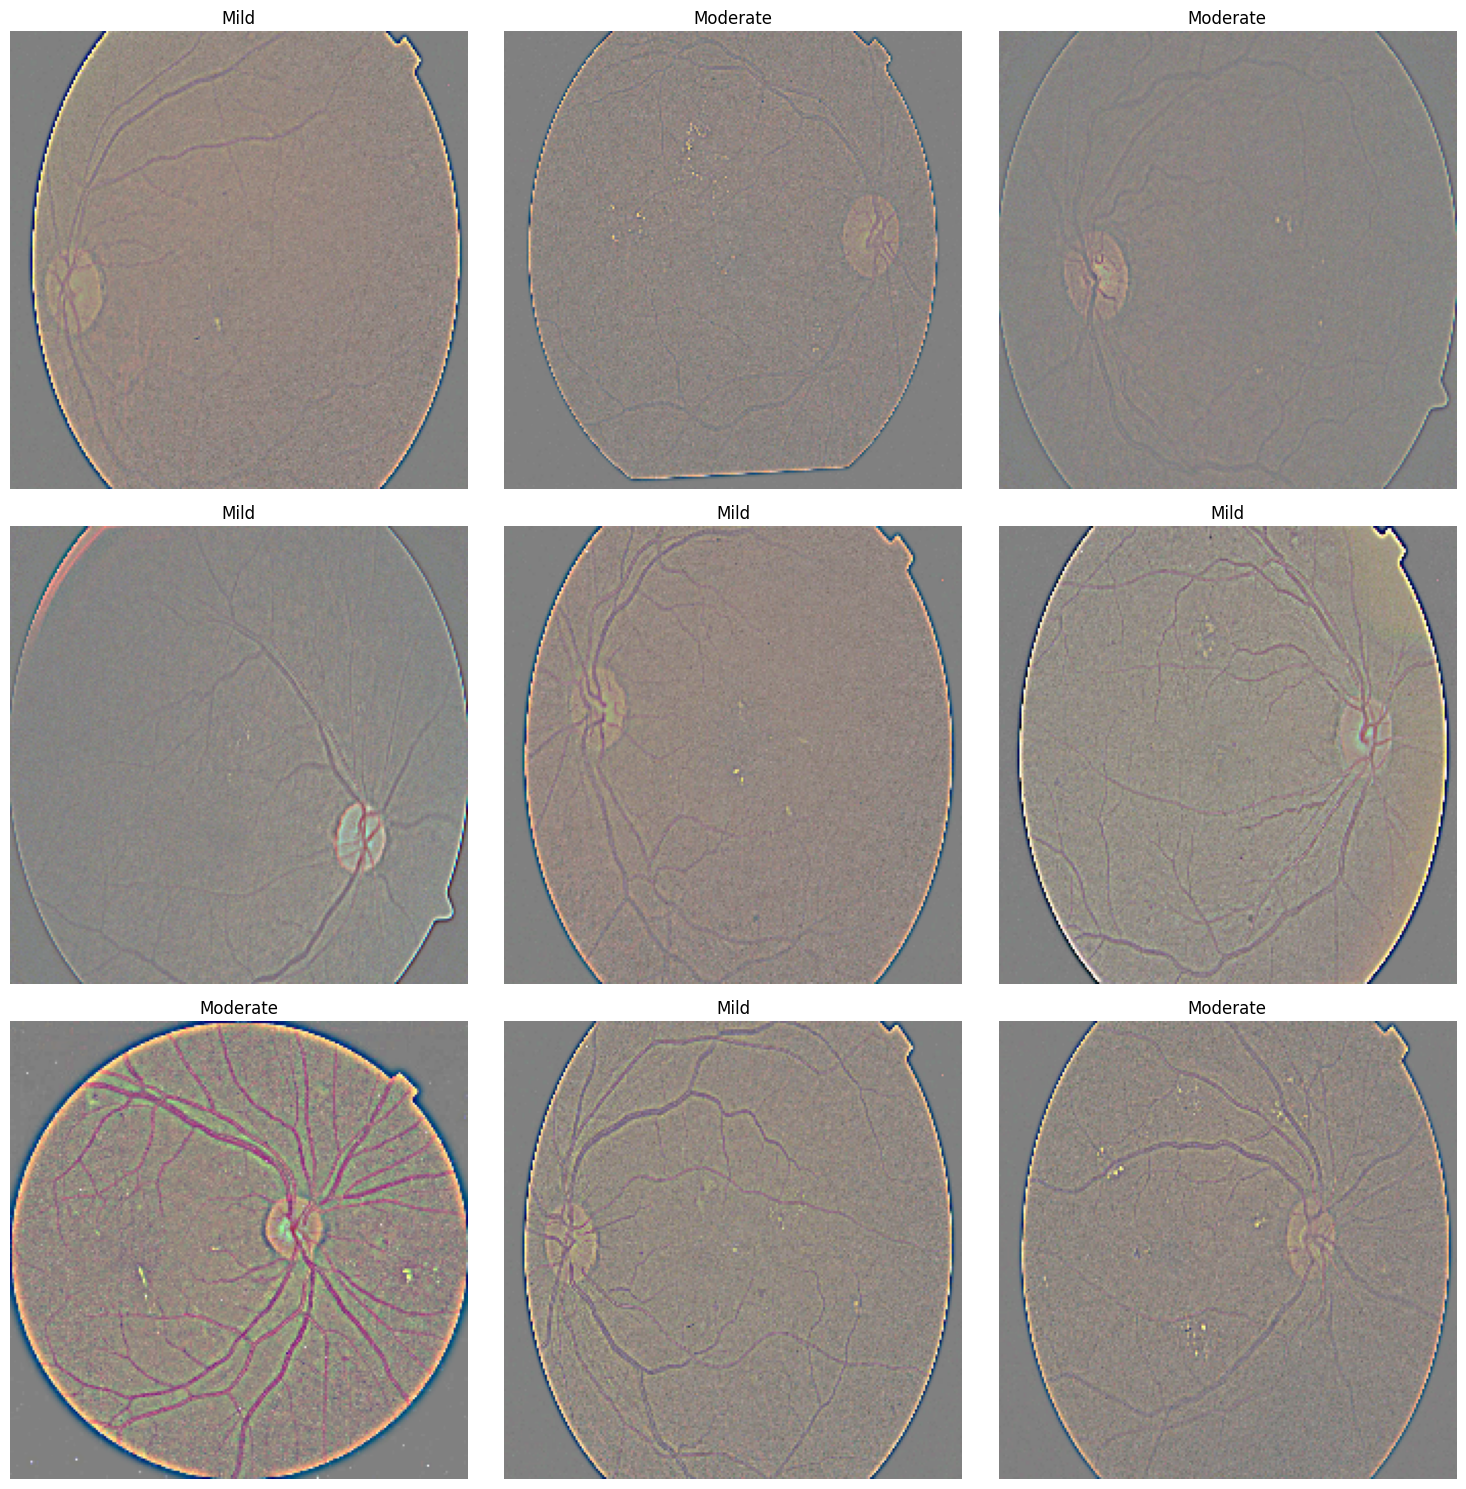

In [6]:
plt.figure(figsize=(15,15))
for i, j in enumerate(np.random.randint(0,1000,9)):
    plt.subplot(3, 3, i+1)
    img = Image.open(all_images[j])
    img = img.resize((224, 224), Image.Resampling.BILINEAR)
    img = np.array(img)

    plt.imshow(img)
    plt.title(label_names[all_labels[j]])
    plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Random Sample Shapes
         </li>
        </ul>
</div>

In [7]:
table_data = []

for i in np.random.randint(0,1000,9):
    img = Image.open(all_images[i])
    img = np.array(img)
    class_name = label_names[all_labels[i]]

    table_data.append([class_name, img.shape])

df_shape = pd.DataFrame(table_data, columns=['Class', 'Shape'])

print(df_shape.head().to_markdown())
print("\n All images have the same size:", len(set(df_shape['Shape'])) == 1)

|    | Class    | Shape         |
|---:|:---------|:--------------|
|  0 | Mild     | (224, 224, 3) |
|  1 | Moderate | (224, 224, 3) |
|  2 | Mild     | (224, 224, 3) |
|  3 | Mild     | (224, 224, 3) |
|  4 | Moderate | (224, 224, 3) |

 All images have the same size: True


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Data Preparation
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Stratified Train/Validation/Test Split
         </li>
        </ul>
</div>

In [8]:
#Train_Test_Split : Create Train/Validation/Test Set

#Train Set
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_images, all_labels,
    test_size=0.3,         
    stratify=all_labels,
    random_state=SEED)

#Validation And Test Set:
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,          
    stratify=temp_labels,
    random_state=SEED)

print(f"Train size: {len(train_paths)}")
print(f"Validation size: {len(val_paths)}")
print(f"Test size: {len(test_paths)}")

Train size: 2563
Validation size: 549
Test size: 550


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Image Preprocessing, Augmentation & Dataset Creation
         </li>
        </ul>
</div>

In [9]:
def parse_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)  
    return image, label


# Data Augmentation
data_augmentation = tf.keras.Sequential([
    keras.layers.RandomFlip("horizontal"),        
    keras.layers.RandomRotation(0.05),             
    keras.layers.RandomZoom(0.10, 0.10),               
    # keras.layers.RandomBrightness(0.2),
    # keras.layers.RandomContrast(0.2),
])

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

# mobilenet_v2 Preprocessing
def preprocess(image, label):
    
    image = keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Create Dataset Function:
def create_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=min(1000, len(paths)),
            reshuffle_each_iteration=True)
        
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    #ds = ds.cache()  

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

# Create Datasets
train_ds = create_ds(train_paths, train_labels, training=True)
val_ds = create_ds(val_paths, val_labels, training=False)
test_ds = create_ds(test_paths, test_labels, training=False)

print(f"Train Set      : {len(train_ds)} batches")
print(f"Validation Set : {len(val_ds)} batches")
print(f"Test Set       : {len(test_ds)} batches")

Train Set      : 81 batches
Validation Set : 18 batches
Test Set       : 18 batches


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Model Architecture and Fine-Tuning with MobileNet
    </p>
</div>

In [10]:
EPOCHS = 15

# Fine-tuning:
base_model.trainable = False

# 1/3
trainable_layers = int(len(base_model.layers) / 3)
for layer in base_model.layers[-trainable_layers:]:
    layer.trainable = True

# BatchNormalization freez
for layer in base_model.layers[-trainable_layers:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


model = keras.models.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(32, activation='leaky_relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(16, activation='leaky_relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(5, activation='softmax')
])

#---


# Model Compile
optim = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    loss='SparseCategoricalCrossentropy',
    optimizer=optim,
    metrics=['accuracy'])
#---

# Callbacks
per_learning = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,           
    patience=1,           
    min_lr=1e-7,
    mode='min')


early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    mode='min',
    restore_best_weights=True)

CALLBACKS = [per_learning, early_stopping]
#---

# Train Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=CALLBACKS)

Epoch 1/15


2026-07-24 19:35:00.436851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-24 19:35:00.634471: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1784921704.415196    1928 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


81/81 ━━━━━━━━━━━━━━━━━━━━ 47s 378ms/step - accuracy: 0.6805 - loss: 0.9549 - val_accuracy: 0.5319 - val_loss: 1.4790 - learning_rate: 1.0000e-04
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.7440 - loss: 0.7631 - val_accuracy: 0.4189 - val_loss: 2.0882 - learning_rate: 1.0000e-04
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - accuracy: 0.7464 - loss: 0.7388 - val_accuracy: 0.7668 - val_loss: 0.7429 - learning_rate: 5.0000e-05
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.7585 - loss: 0.7113 - val_accuracy: 0.7668 - val_loss: 0.7995 - learning_rate: 5.0000e-05
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.7659 - loss: 0.6559 - val_accuracy: 0.7486 - val_loss: 0.7609 - learning_rate: 2.5000e-05
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.7710 - loss: 0.6415 - val_accuracy: 0.7577 - val_loss: 0.7405 - learning_rate: 1.2500e-05
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.77

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        5. Model Evaluation
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Performance Analysis
         </li>
        </ul>
</div>


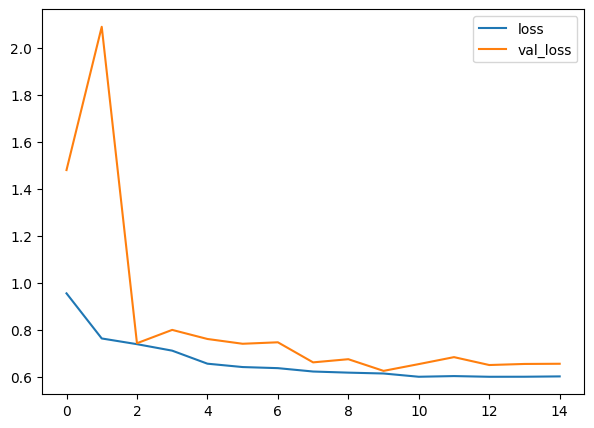

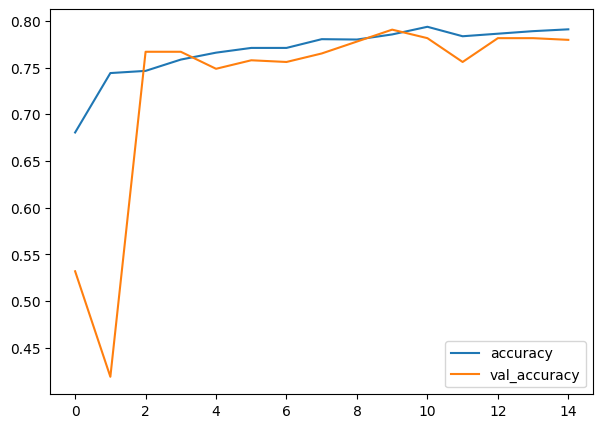

In [11]:
#print(history.history.keys())
#Loss
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
#ACC
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Classification Report and Confusion Matrix
         </li>
        </ul>
</div>

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 412ms/step
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        56
           1       0.61      0.80      0.69       150
           2       0.96      0.97      0.97       271
           3       0.58      0.16      0.25        44
           4       0.33      0.03      0.06        29

    accuracy                           0.77       550
   macro avg       0.61      0.51      0.51       550
weighted avg       0.76      0.77      0.75       550



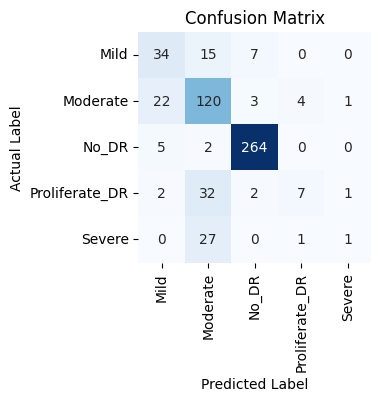

In [12]:
y_pred = model.predict(test_ds)
pred = y_pred.argmax(axis=1)
#---
print(classification_report(test_labels, pred))
#---
matrix_labels = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
cm = confusion_matrix(test_labels, pred)
plt.figure(figsize=(3,3))
sns.heatmap(cm, cbar=False, annot=True,
            cmap='Blues', annot_kws={'size':10},
            fmt='.0f', xticklabels=matrix_labels, 
            yticklabels=matrix_labels)
plt.title('Confusion Matrix')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Multi-Class ROC Curve Evaluation
         </li>
        </ul>
</div>

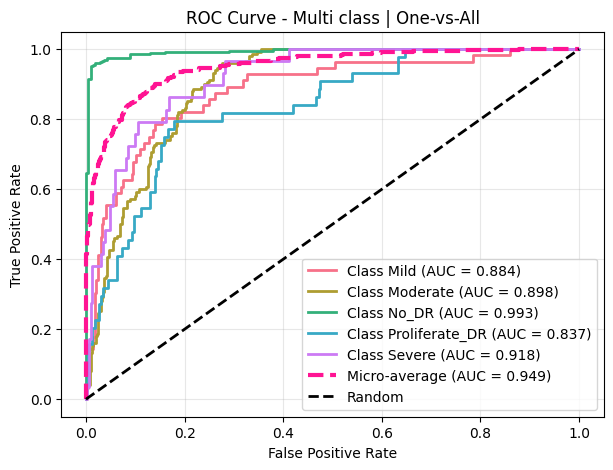

In [13]:
n_classes=5
colors = sns.color_palette("husl", n_classes)
label_oh = keras.utils.to_categorical(test_labels)
plt.figure(figsize=(7, 5))
#---
#Roc Curve Plot:
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(label_oh[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'Class {label_names[i]} (AUC = {roc_auc:.3f})')
#---
# ROC Micro AVG PLot:
fpr_micro, tpr_micro, _ = roc_curve(label_oh.ravel(), y_pred.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle='--', linewidth=3,
         label=f'Micro-average (AUC = {roc_auc_micro:.3f})')
#---
# Random Line Plot: 
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi class | One-vs-All')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;font-weight:bold;">
            <li>
       Sample Predictions on Test Images
         </li>
        </ul>
</div>

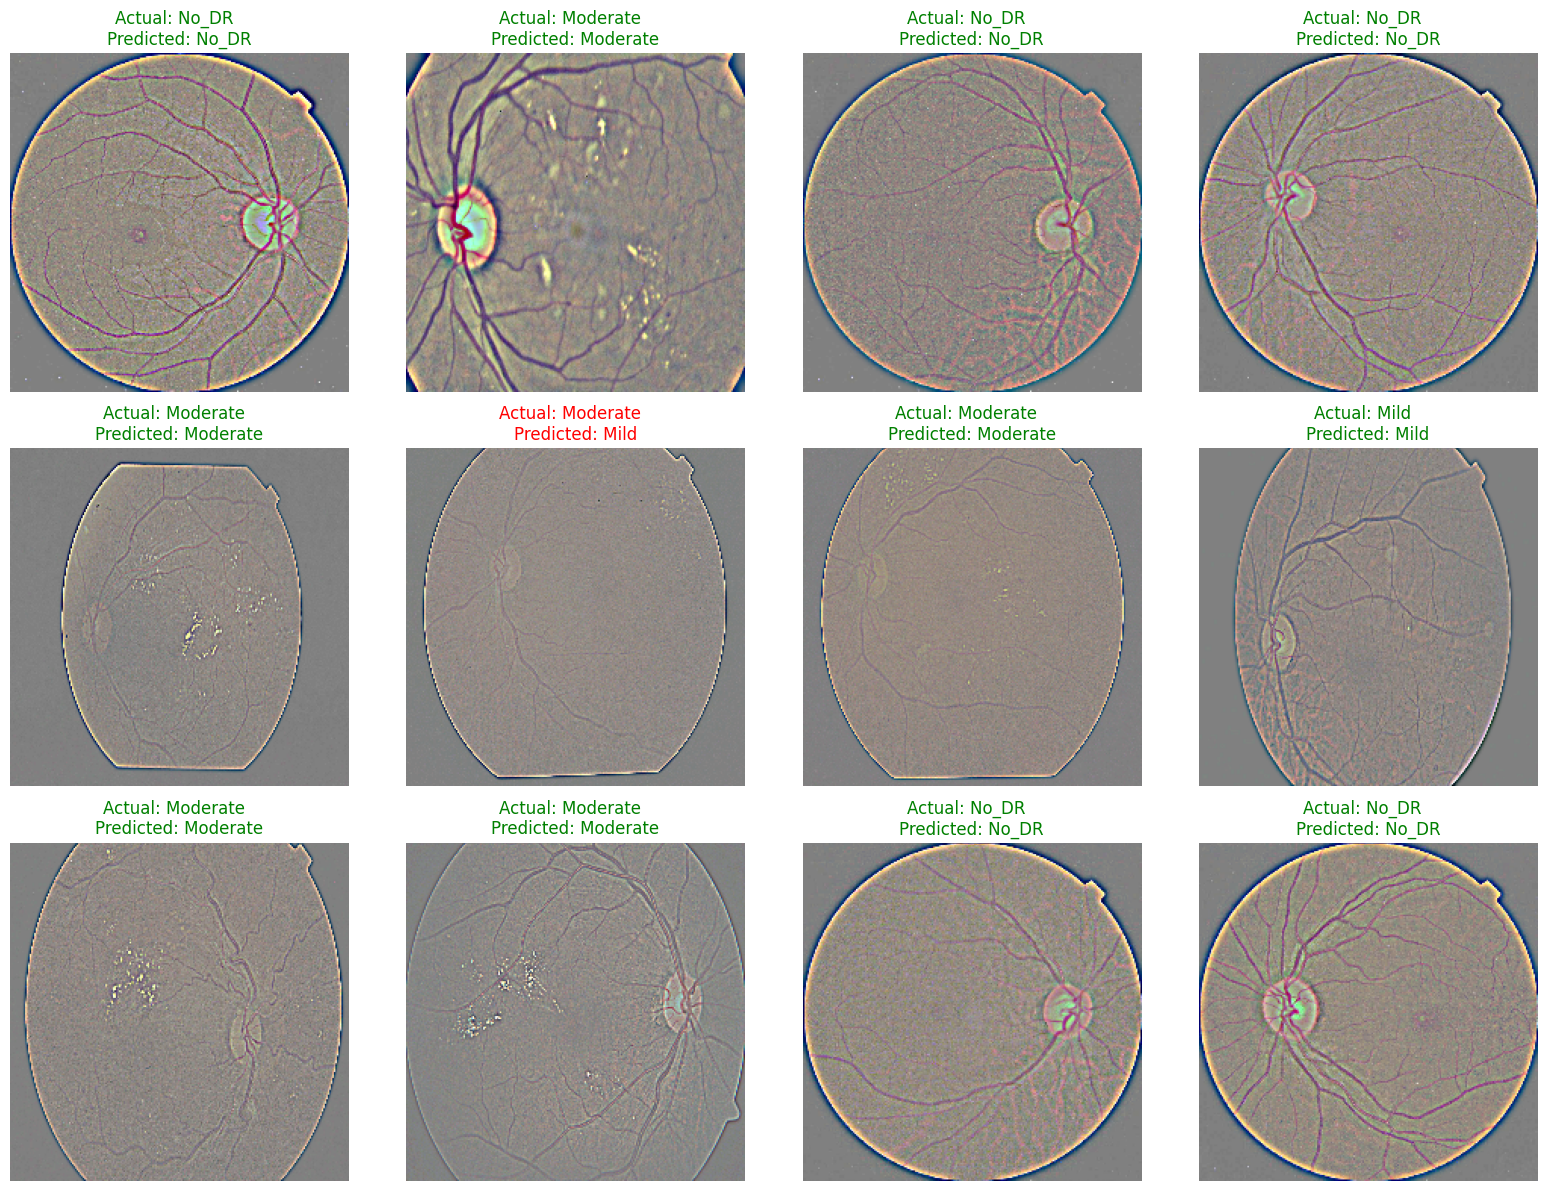

In [17]:
predicts, labels = pred, test_labels
fig,ax=plt.subplots(3,4)
fig.set_size_inches(16,12)
for i in range(3):
    for j in range (4):
        idx=np.random.randint(0,200)
        image = plt.imread(test_paths[idx])
        ax[i,j].imshow(image)
        ax[i, j].axis('off')
        if labels[idx] == predicts[idx]:
            ax[i,j].set_title('Actual: '+label_names[labels[idx]]+'  \nPredicted: '+label_names[predicts[idx]], color = 'green')
        else:
            ax[i,j].set_title('Actual: '+label_names[labels[idx]]+'  \nPredicted: '+label_names[predicts[idx]], color = 'red')
plt.tight_layout()

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        6. Saving Model for Deployment (ONNX)
    </p>
</div>

In [15]:
@tf.function
def model_func(input_tensor):
    return model(input_tensor)

spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name='input'),)

onnx_model, _ = tf2onnx.convert.from_function(
    model_func,
    input_signature=spec,
    opset=17,
    output_path='final_onnx_model.onnx'
)

# # output_names = [n.name for n in onnx_model.graph.output]
# # input_names  = [n.name for n in onnx_model.graph.input]

I0000 00:00:1784921956.683936    1869 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1784921956.684094    1869 single_machine.cc:376] Starting new session
I0000 00:00:1784921956.685135    1869 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1784921957.548537    1869 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1784921957.668174    1869 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1784921957.668431    1869 single_machine.cc:376] Starting new session
I0000 00:00:1784921957.669513    1869 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 wi

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
       Thanks a lot for going through this notebook! I hope it was helpful and worth your time.
    </p>
</div>